In [1]:
import numpy as np
import matplotlib.pyplot as plt

### The following table lists 105 observations of $X$, the times between calls to 911:

In [2]:
data = [30, 17, 65, 8, 38, 35, 4, 19, 7, 14, 12, 4, 5, 4, 2,
        7, 5, 12, 50, 33, 10, 15, 2, 10, 1, 5, 30, 41, 21, 31,
        1, 18, 12, 5, 24, 7, 6, 31, 1, 3, 2, 22, 1, 30, 2,
        1, 3, 12, 12, 9, 28, 6, 50, 63, 5, 17, 11, 23, 2, 46,
        90, 13, 21, 55, 43, 5, 19, 47, 24, 4, 6, 27, 4, 6, 37,
        16, 41, 68, 9, 5, 28, 42, 3, 42, 8, 52, 2, 11, 41, 4,
        35, 21, 3, 17, 10, 16, 1, 68, 105, 45, 23, 5, 10, 12, 17]

In [3]:
n = 105

#### Sample mean and standard deviation

In [4]:
sample_mean = np.mean(data)
sample_mean

20.485714285714284

In [7]:
sample_std = np.std(data)
sample_std = np.std(data, ddof = 1)
sample_std

20.343735704574577

In [6]:
means = [sample_mean]*n
differences = [0]*n
for i in range(n):
    differences[i] = (data[i] - means[i])**2
np.sqrt(np.mean(differences))

20.246629013111242

Note: np.std computes $\sqrt{\frac{n-1}{n}s^2}$, where $s^2$ is defined as in the textbook

#### Empirical distribution

In [8]:
from collections import Counter

c = Counter(data)

In [9]:
sorted(c.items())

[(1, 6),
 (2, 6),
 (3, 4),
 (4, 6),
 (5, 8),
 (6, 4),
 (7, 3),
 (8, 2),
 (9, 2),
 (10, 4),
 (11, 2),
 (12, 6),
 (13, 1),
 (14, 1),
 (15, 1),
 (16, 2),
 (17, 4),
 (18, 1),
 (19, 2),
 (21, 3),
 (22, 1),
 (23, 2),
 (24, 2),
 (27, 1),
 (28, 2),
 (30, 3),
 (31, 2),
 (33, 1),
 (35, 2),
 (37, 1),
 (38, 1),
 (41, 3),
 (42, 2),
 (43, 1),
 (45, 1),
 (46, 1),
 (47, 1),
 (50, 2),
 (52, 1),
 (55, 1),
 (63, 1),
 (65, 1),
 (68, 2),
 (90, 1),
 (105, 1)]

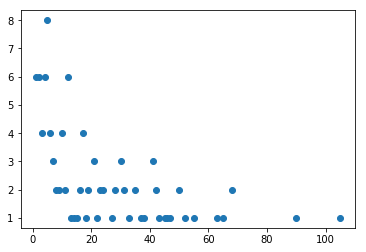

In [10]:
plt.plot(c.keys(), c.values(), 'o')

In [11]:
values = [x/n for x in c.values()]
items = [x for x in c.keys()]

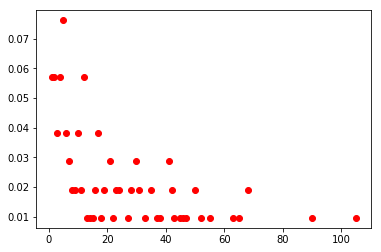

In [12]:
plt.plot(items, values, 'ro')

#### Empirical rule?

$(\bar{X} - s, \bar{X} + s) = (0.14, 40.9)$ Contains all but $19$ data points ($82\%$ of data)

$(\bar{X} - 2s, \bar{X} + 2s)$ Contains all but $6$ data points ($94.3\%$ of data)

$(\bar{X} - 3s, \bar{X} + 3s)$ Contains all but $2$ data points ($98\%$ of data)

In [14]:
counter = 0
for i in range(n):
    if data[i] > sample_mean + 2*sample_std:
        counter += 1
counter

6

Note: the data is NOT bell-shaped (so, empirical rule does not apply)

"Homework": take data from Table 6.1-3 and check if empirical rule works well

#### Histogram

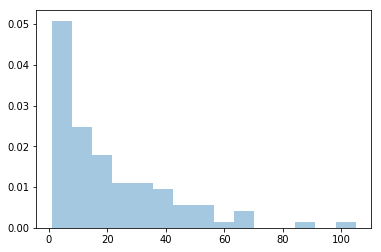

In [15]:
import seaborn as sns
sns.distplot(data, norm_hist = True, kde = False, bins = 15)

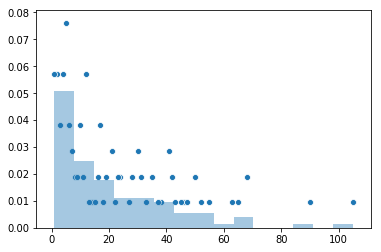

In [20]:
sns.distplot(data, norm_hist = True, kde = False, bins = 15)
sns.scatterplot(items, values)

(array([37., 18., 13.,  8.,  8.,  7.,  4.,  4.,  1.,  3.,  0.,  0.,  1.,
         0.,  1.]),
 array([  1.        ,   7.93333333,  14.86666667,  21.8       ,
         28.73333333,  35.66666667,  42.6       ,  49.53333333,
         56.46666667,  63.4       ,  70.33333333,  77.26666667,
         84.2       ,  91.13333333,  98.06666667, 105.        ]),
 <a list of 15 Patch objects>)

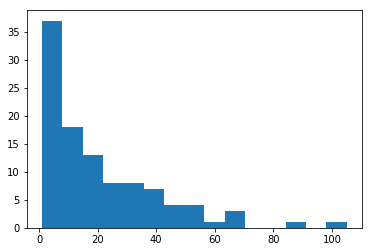

In [21]:
plt.hist(data, bins = 15)

class intervals $(c_i, c_{i+1}]$: (1, 7.9], (7.9, 14.8], ...

height $h(x) = \frac{f_i}{n(c_i - c_{i+1})}$ for all $x \in [c_i, c_{i+1}]$. Here, $f_i$ is number of points in the class. $f_1 = 37, f_2 = 18, \ldots$

Note: histogram models density: covered area is equal to one! (Check this)

#### Other statistics to compute

In [22]:
median = np.median(data)
median

12.0

Definition: median point is such that exactly one half of the data is less than the median

In [23]:
min_point = np.min(data)
min_point

1

In [24]:
max_point = np.max(data)
max_point

105

In [25]:
range_of_data = max_point - min_point

In [26]:
upper_half = [x for x in data if x >= median]
np.median(upper_half)

29.0

In [27]:
lower_half = [x for x in data if x < median]
np.median(lower_half)

5.0

{'whiskers': [<matplotlib.lines.Line2D at 0x1a1ccc57f0>,
 'caps': [<matplotlib.lines.Line2D at 0x1a1ccc5e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a1ccc5438>],
 'medians': [<matplotlib.lines.Line2D at 0x1a1cccd4e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a1cccd828>],
 'means': []}

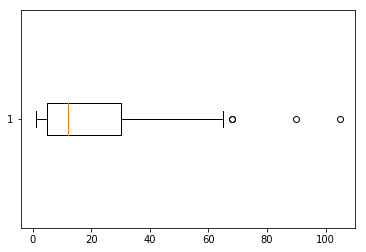

In [28]:
plt.boxplot(data, vert = False)

IQR = interquartile range = third_quartile - first_quartile

Whiskers = box edges +- 1.5*IQR

Outliers = everything outside

5 points summary = {min, 1st quartile, median, 3rd quartile, max}

### What if we guess a distribuition?

Maybe, exponential?

Density function $f(x) = \frac{1}{\lambda} \exp(-x/\lambda)$

Maybe, $\lambda = 20?$

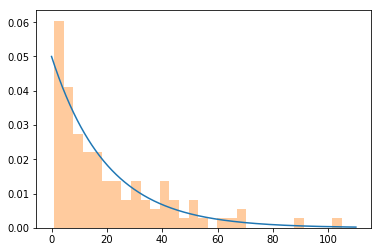

In [33]:
x = np.linspace(0, 110, 500)
lam = 20
sns.lineplot(x, np.exp(-x/lam)/lam)
sns.distplot(data, norm_hist = True, kde = False, bins = 30)

Parameter $\lambda$ in exponential distribution is equal to expectation. We take a sample mean for the expectation (looking forward: parameter estimation)

Why exponential? Well, it is known to model waiting times between two consequitive events in the Poisson process (see, for example, this stackexchange answer https://stats.stackexchange.com/questions/2092/relationship-between-poisson-and-exponential-distribution and wiki article about Poisson distribution here https://en.wikipedia.org/wiki/Poisson_distribution#Law_of_rare_events)